# X-ray diseases classifier

This notebook demonstrates an image classification approach for analyzing chest X-ray images. The project uses the NIH Chest X-ray dataset and focuses on exploring a proof-of-concept method for detecting thoracic findings from medical imaging data.

Rabi Arbi, 2026

![banner](https://d1qpnt4t1p05jk.cloudfront.net/wp-content/uploads/2025/10/27082644/image-2544-1024x683.jpeg)

In [1]:
import collections, lightning, pandas as pd, platform, os, torch, torchvision, warnings

from torch.utils.data import Dataset, DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
from torchvision import transforms
from torchmetrics.classification import MultilabelAccuracy, MultilabelPrecision, MultilabelRecall
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

import matplotlib.pyplot as plt

lightning.seed_everything(42)
torch.set_float32_matmul_precision("high")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for this notebook. Select a CUDA-enabled interpreter/kernel.")

data_path = "data"

use_cuda = True
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True

trainer_kwargs = {
    "accelerator": "gpu",
    "devices": 1,
    "precision": "16-mixed",
}

print(
    "Versions: python", platform.python_version(),
    "| torch", torch.__version__,
    "| torchvision", torchvision.__version__,
    "| lightning", lightning.__version__,
)
print("CUDA available:", torch.cuda.is_available())
print("Active device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Trainer kwargs:", trainer_kwargs)

W0419 22:07:09.279000 49164 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


Versions: python 3.14.0 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | lightning 2.6.1
CUDA available: True
Active device: cuda
GPU: NVIDIA GeForce RTX 5080
Trainer kwargs: {'accelerator': 'gpu', 'devices': 1, 'precision': '16-mixed'}


### explanation

- `collections` → counts labels and checks class balance  
- `lightning` → organizes training structure  
- `pandas` → reads and processes the dataset CSV  
- `platform` → shows Python/version info  
- `os` → handles file paths  
- `torch` → core deep learning library  
- `torchvision` → image utilities and transforms  
- `warnings` → controls warning messages  

- `Dataset` → builds a custom NIH dataset class  
- `DataLoader` → loads images in batches  

- `LightningDataModule` → manages data loading and splits  
- `LightningModule` → defines model, loss, and training steps  
- `Trainer` → runs training and validation  

- `transforms` → preprocesses X-ray images  
- `MultilabelAccuracy` → evaluates multi-label predictions  
- `MultilabelPrecision` → checks how many positive predictions are correct  
- `MultilabelRecall` → checks how many real positives are found  

- `CSVLogger` → saves training results  
- `EarlyStopping` → stops training when improvement stalls  
- `matplotlib.pyplot` → plots images and training curves  

- `seed_everything(42)` → makes runs reproducible  
- `set_float32_matmul_precision("high")` → improves GPU computation performance  
- `data_path = "data"` → sets dataset folder  
- `print(...)` → shows library versions

------------------------------------------------------------------------------------

# Loading Swin Transformer

In [2]:
import torch.nn as nn
import torchvision

num_classes = 11

pretrained_model = torchvision.models.swin_t(weights="DEFAULT")
pretrained_model.head = nn.Linear(pretrained_model.head.in_features, num_classes)

criterion = nn.CrossEntropyLoss()

## What each part does:

- `swin_t(weights="DEFAULT")` → loads pretrained Swin Transformer
- `nn.Linear(...)` → replaces the classification head
- `num_classes` = 11 → one output per chest finding
- `CrossEntropyLoss()` → correct loss for single-label multi-class prediction

### Why the head was replaced

The original classification head was built for a different task.

This pretrained `Swin Transformer` came from ImageNet, so its head was made to predict **1000 ImageNet classes** such as dogs, cars, chairs, and other everyday objects.

This project is different:
- **input** = chest X-ray image  
- **output** = 11 thoracic findings  

So the original head does not match this target.

Inside the model:
- the early and middle layers learn general visual features  
- the head maps those features to the final class outputs  

That final mapping is task-specific.

The head was replaced because:
- the ImageNet output size is wrong  
- this project needs **11 outputs**  
- the new classes are completely different  
- this is how transfer learning adapts a pretrained model to a new task  

Simple example:

**Before**
- model sees an image  
- head predicts one of **1000 ImageNet classes**  

**After**
- model sees a chest X-ray  
- head predicts the 11 chest findings, such as **Atelectasis, Effusion, Mass, Pneumonia**, and others.

------------------------------------------------------------------------------------------------------

## Clean The Data


### No Finding Analysis

We will measure how many images are labeled **No Finding**. These samples may add less value for disease classification, so we review their proportion before deciding whether to keep or remove them.

In [3]:
from pathlib import Path

# Locate NIH metadata CSV from common project layouts.
candidate_csv_paths = [
    Path(data_path) / "Data_Entry_2017.csv",
    Path("Data_Entry_2017.csv"),
    Path("archive") / "Data_Entry_2017.csv",
]

csv_path = next((p for p in candidate_csv_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find Data_Entry_2017.csv. Checked: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

df = pd.read_csv(csv_path)

if "Finding Labels" not in df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the metadata CSV.")

no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
no_finding_count = int(no_finding_mask.sum())
total_images = len(df)
other_findings_count = total_images - no_finding_count
no_finding_ratio = (no_finding_count / total_images) if total_images else 0.0

summary_table = pd.DataFrame(
    {
        "Metric": [
            "CSV used",
            "Total images",
            "Images with No Finding",
            "Images with Other Findings",
            "No Finding ratio",
        ],
        "Value": [
            str(csv_path),
            f"{total_images:,}",
            f"{no_finding_count:,}",
            f"{other_findings_count:,}",
            f"{no_finding_ratio:.2%}",
        ],
    }
)
display(summary_table)


,Metric,Value
0,CSV used,Data_Entry_2017.csv
1,Total images,"112,120"
2,Images with No Finding,"60,361"
3,Images with Other Findings,"51,759"
4,No Finding ratio,53.84%


### Why It Can Be Better to Remove Some No Finding Images:
In this task, removing a portion of **No Finding** images can improve learning because the model then sees more disease-positive examples, reducing class imbalance and helping it focus on patterns related to thoracic abnormalities.

In [4]:
# Prints only the number of images after removal (skip if removal not run yet).
if "total_after" in globals():
    print(total_after)
elif "df_clean" in globals():
    total_after = len(df_clean)
    print(total_after)
else:
    print("No Finding removal has not run yet. Skipping count.")

No Finding removal has not run yet. Skipping count.


In [5]:
# Remove all rows labeled 'No Finding'. Skip if already removed.
if "df_clean" in globals() and "total_after" in globals():
    print("No Finding rows already removed. Skipping.")
else:
    if "df" not in globals():
        raise NameError("Run the metadata loading cell first to create df.")

    if "Finding Labels" not in df.columns:
        raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

    no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
    df_clean = df.loc[~no_finding_mask].copy()

    total_before = len(df)
    total_after = len(df_clean)
    removed_count = total_before - total_after

    print(f"Total images before: {total_before}")
    print(f"No Finding images removed: {removed_count}")
    print(f"Total images after removal: {total_after}")

 

Total images before: 112120
No Finding images removed: 60361
Total images after removal: 51759


Also some images in the dataset contain multiple disease labels, which can confuse the model because it is unclear which disease is the correct target. To improve model clarity and performance, these images will be removed. Only images with a single, clear disease label will be used, ensuring that each input corresponds to one specific prediction.


In [6]:
# Count images that have more than one disease label (excluding 'No Finding').
if "Finding Labels" not in df_clean.columns:
    raise KeyError("Column 'Finding Labels' was not found in df_clean.")

label_count = (
    df_clean["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

multi_disease_count = int((label_count > 1).sum())
print(multi_disease_count)

20796


# Keep only one single-label image per patient and drop the rest.


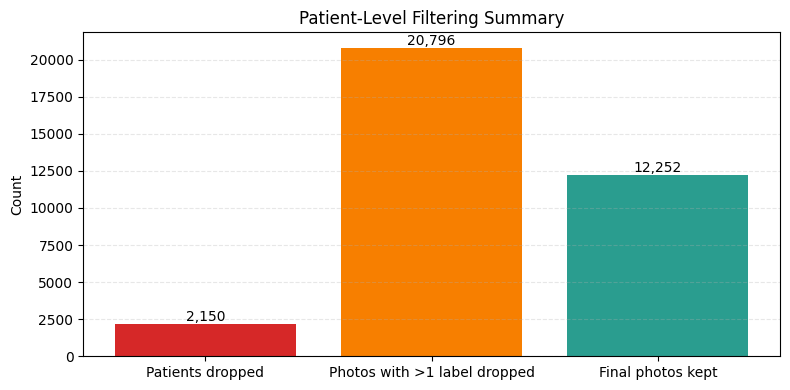

Patients dropped: 2150
Photos with >1 label dropped: 20796
Final photos kept (1 per patient): 12252


In [7]:
base_df = df_clean.copy() if "df_clean" in globals() else df.copy()

if "Finding Labels" not in base_df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in base_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column was not found in the dataframe.")

label_count_base = (
    base_df["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

single_label_df = base_df.loc[label_count_base == 1].copy()

if "Image Index" in single_label_df.columns:
    single_label_df = single_label_df.sort_values([patient_col, "Image Index"])
else:
    single_label_df = single_label_df.sort_values([patient_col])

df_one_image_per_patient = single_label_df.drop_duplicates(subset=patient_col, keep="first").copy()

patients_before = int(base_df[patient_col].nunique())
patients_after = int(df_one_image_per_patient[patient_col].nunique())
patients_dropped = patients_before - patients_after

multi_label_photos_dropped = int((label_count_base > 1).sum())
final_photos_kept = int(len(df_one_image_per_patient))

labels = ["Patients dropped", "Photos with >1 label dropped", "Final photos kept"]
values = [patients_dropped, multi_label_photos_dropped, final_photos_kept]
colors = ["#d62828", "#f77f00", "#2a9d8f"]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Patient-Level Filtering Summary")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Patients dropped: {patients_dropped}")
print(f"Photos with >1 label dropped: {multi_label_photos_dropped}")
print(f"Final photos kept (1 per patient): {final_photos_kept}")

# Chart: total images before any cleaning vs final images after all cleaning.


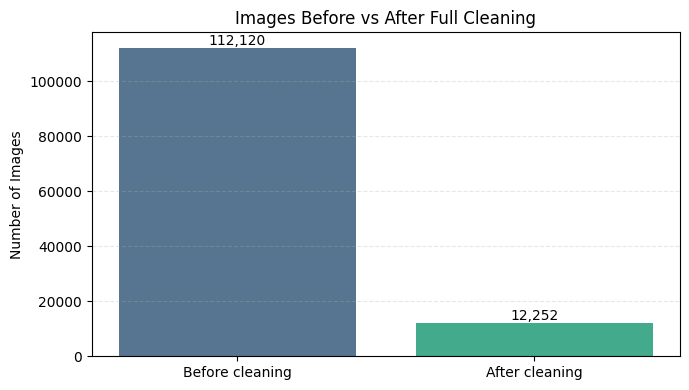

Before cleaning: 112120
After cleaning: 12252


In [8]:
before_cleaning = len(df) if "df" in globals() else total_images
after_cleaning = len(df_one_image_per_patient) if "df_one_image_per_patient" in globals() else final_photos_kept

labels = ["Before cleaning", "After cleaning"]
values = [before_cleaning, after_cleaning]
colors = ["#577590", "#43aa8b"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Images Before vs After Full Cleaning")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Before cleaning: {before_cleaning}")
print(f"After cleaning: {after_cleaning}")

# Randomly show 10 patients with one image ID and its label.


In [9]:
sample_df = df_one_image_per_patient.copy()

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in sample_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column not found.")

image_col_candidates = ["Image Index", "ImageID", "image_id"]
image_col = next((c for c in image_col_candidates if c in sample_df.columns), None)
if image_col is None:
    raise KeyError("Image ID column not found.")

if "Finding Labels" not in sample_df.columns:
    raise KeyError("'Finding Labels' column not found.")

total_images_kept = len(sample_df)
n = min(10, total_images_kept)
random_10 = sample_df.sample(n=n).loc[:, [patient_col, image_col, "Finding Labels"]]
random_10 = random_10.reset_index(drop=True)

print(f"Total images after all filtering: {total_images_kept}")
print(f"Random sample of {n} patients (new each run):")
display(random_10)

Total images after all filtering: 12252
Random sample of 10 patients (new each run):


,Patient ID,Image Index,Finding Labels
0,22963,00022963_000.png,Infiltration
1,957,00000957_001.png,Atelectasis
2,7354,00007354_007.png,Infiltration
3,18190,00018190_000.png,Infiltration
4,18156,00018156_001.png,Atelectasis
5,22484,00022484_006.png,Consolidation
6,7166,00007166_001.png,Emphysema
7,11244,00011244_000.png,Atelectasis
8,3376,00003376_000.png,Effusion
9,2996,00002996_000.png,Pleural_Thickening


## Number of images Per class

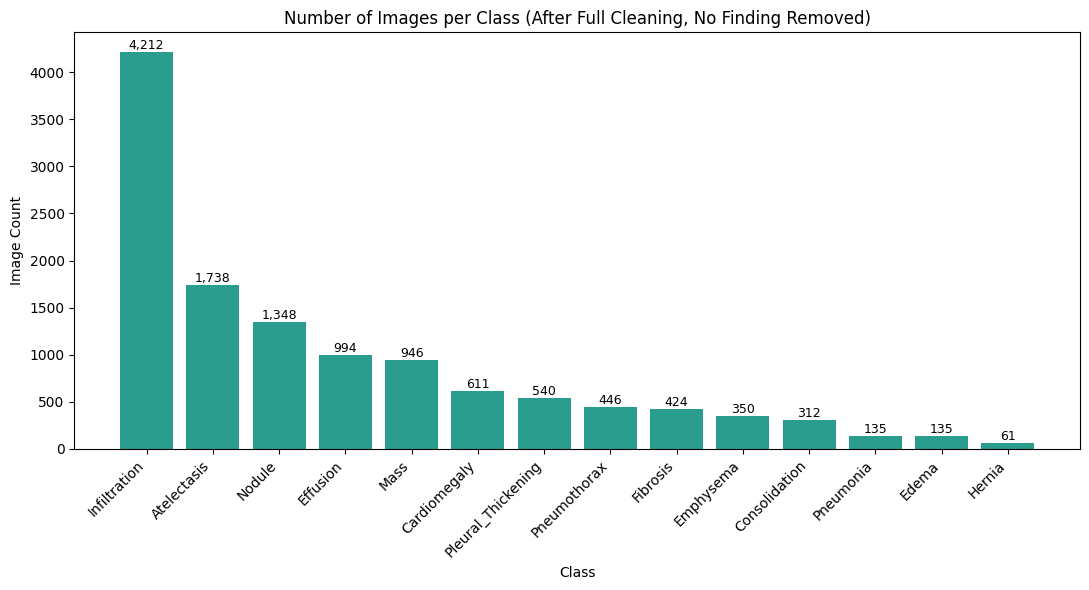

Total rows used for plotting: 12,252
Total disease labels plotted: 12,252
Total unique classes: 14


In [10]:
# Number of images per class after full cleaning (excluding 'No Finding')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def build_clean_df(base_df: pd.DataFrame) -> pd.DataFrame:
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column was not found in the dataframe.")

    disease_df = base_df.loc[
        ~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")
    ].copy()
    label_count = disease_df["Finding Labels"].fillna("").astype(str).str.split("|").str.len()
    single_label_df = disease_df.loc[label_count == 1].copy()

    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in single_label_df.columns else [])
    return single_label_df.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first")

if "df_one_image_per_patient" in globals():
    plot_df = df_one_image_per_patient.copy()
else:
    if "df" in globals():
        base_df = df.copy()
    else:
        csv_candidates = [
            Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
            Path("Data_Entry_2017.csv"),
            Path("archive") / "Data_Entry_2017.csv",
        ]
        csv_path = next((p for p in csv_candidates if p.exists()), None)
        if csv_path is None:
            raise FileNotFoundError("Could not find Data_Entry_2017.csv")
        base_df = pd.read_csv(csv_path)

    if "Finding Labels" not in base_df.columns:
        raise KeyError("Column 'Finding Labels' not found in the dataframe.")
    plot_df = build_clean_df(base_df)

class_counts = (
    plot_df["Finding Labels"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: s.ne("") & s.str.casefold().ne("no finding")]
    .value_counts()
    .sort_values(ascending=False)
 )

if class_counts.empty:
    raise ValueError("No disease labels found after cleaning.")

plt.figure(figsize=(11, 6))
bars = plt.bar(class_counts.index, class_counts.values, color="#2a9d8f")
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{count:,}", ha="center", va="bottom", fontsize=9)

plt.title("Number of Images per Class (After Full Cleaning, No Finding Removed)")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Total rows used for plotting: {len(plot_df):,}")
print(f"Total disease labels plotted: {int(class_counts.sum()):,}")
print(f"Total unique classes: {class_counts.size}")

We observe that three disease classes (Pneumonia, Edema, and Hernia) each contain fewer than 150 images. This sample size is insufficient for effective model training and would likely result in poor generalization performance. Therefore, these underrepresented classes will be excluded from the dataset to maintain training data quality.

In [11]:
# Remove classes with insufficient data: Pneumonia, Edema, and Hernia
classes_to_drop = ["Pneumonia", "Edema", "Hernia"]

if "df_one_image_per_patient" in globals():
    df_filtered = df_one_image_per_patient.copy()
else:
    raise NameError("df_one_image_per_patient not found. Run the previous clustering cells first.")

if "Finding Labels" not in df_filtered.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

before_rows = len(df_filtered)
df_filtered = df_filtered[~df_filtered["Finding Labels"].isin(classes_to_drop)].copy()
after_rows = len(df_filtered)
dropped_rows = before_rows - after_rows

print(f"Classes removed: {', '.join(classes_to_drop)}")
print(f"Total images before removal: {before_rows}")
print(f"Total images after removal: {after_rows}")
print(f"Images dropped: {dropped_rows}")


Classes removed: Pneumonia, Edema, Hernia
Total images before removal: 12252
Total images after removal: 11921
Images dropped: 331


# Resize the images
 the images sizes are Too big (1024 * 1024) it will get too heavy to train the model the best solution is to resize it down to 384 * 384

In [12]:
from pathlib import Path
from PIL import Image

# Choose which image list to resize: filtered training set if available, otherwise all metadata rows.
resize_df = df_one_image_per_patient if "df_one_image_per_patient" in globals() else df

if "Image Index" not in resize_df.columns:
    raise KeyError("Column 'Image Index' not found in the dataframe.")

target_size = (384, 384)

# Support running notebook either from project root or from archive/ folder.
base_candidates = [Path("."), Path("archive")]
image_roots = []
for base in base_candidates:
    image_roots.extend(sorted(base.glob("images_*/images")))

if not image_roots:
    raise FileNotFoundError("Could not find any source folders matching images_*/images.")

output_base = Path("archive") if Path("archive").exists() else Path(".")
output_dir = output_base / "images_384"
output_dir.mkdir(parents=True, exist_ok=True)

# Build fast lookup for original image files across NIH folders.
image_lookup = {}
for root in image_roots:
    for p in root.glob("*.png"):
        image_lookup[p.name] = p

image_names = resize_df["Image Index"].dropna().astype(str).unique().tolist()

resized_count = 0
missing_count = 0
skipped_count = 0

for img_name in image_names:
    src = image_lookup.get(img_name)
    if src is None:
        missing_count += 1
        continue

    dst = output_dir / img_name
    if dst.exists():
        skipped_count += 1
        continue

    with Image.open(src) as im:
        im = im.convert("RGB")
        im = im.resize(target_size, Image.Resampling.LANCZOS)
        im.save(dst, format="PNG")
    resized_count += 1

print(f"Target size: {target_size}")
print(f"Source unique images: {len(image_names)}")
print(f"Resized now: {resized_count}")
print(f"Skipped (already resized): {skipped_count}")
print(f"Missing source files: {missing_count}")
print(f"Output folder: {output_dir}")

Target size: (384, 384)
Source unique images: 12252
Resized now: 0
Skipped (already resized): 12252
Missing source files: 0
Output folder: archive\images_384


# Data Sampeling 

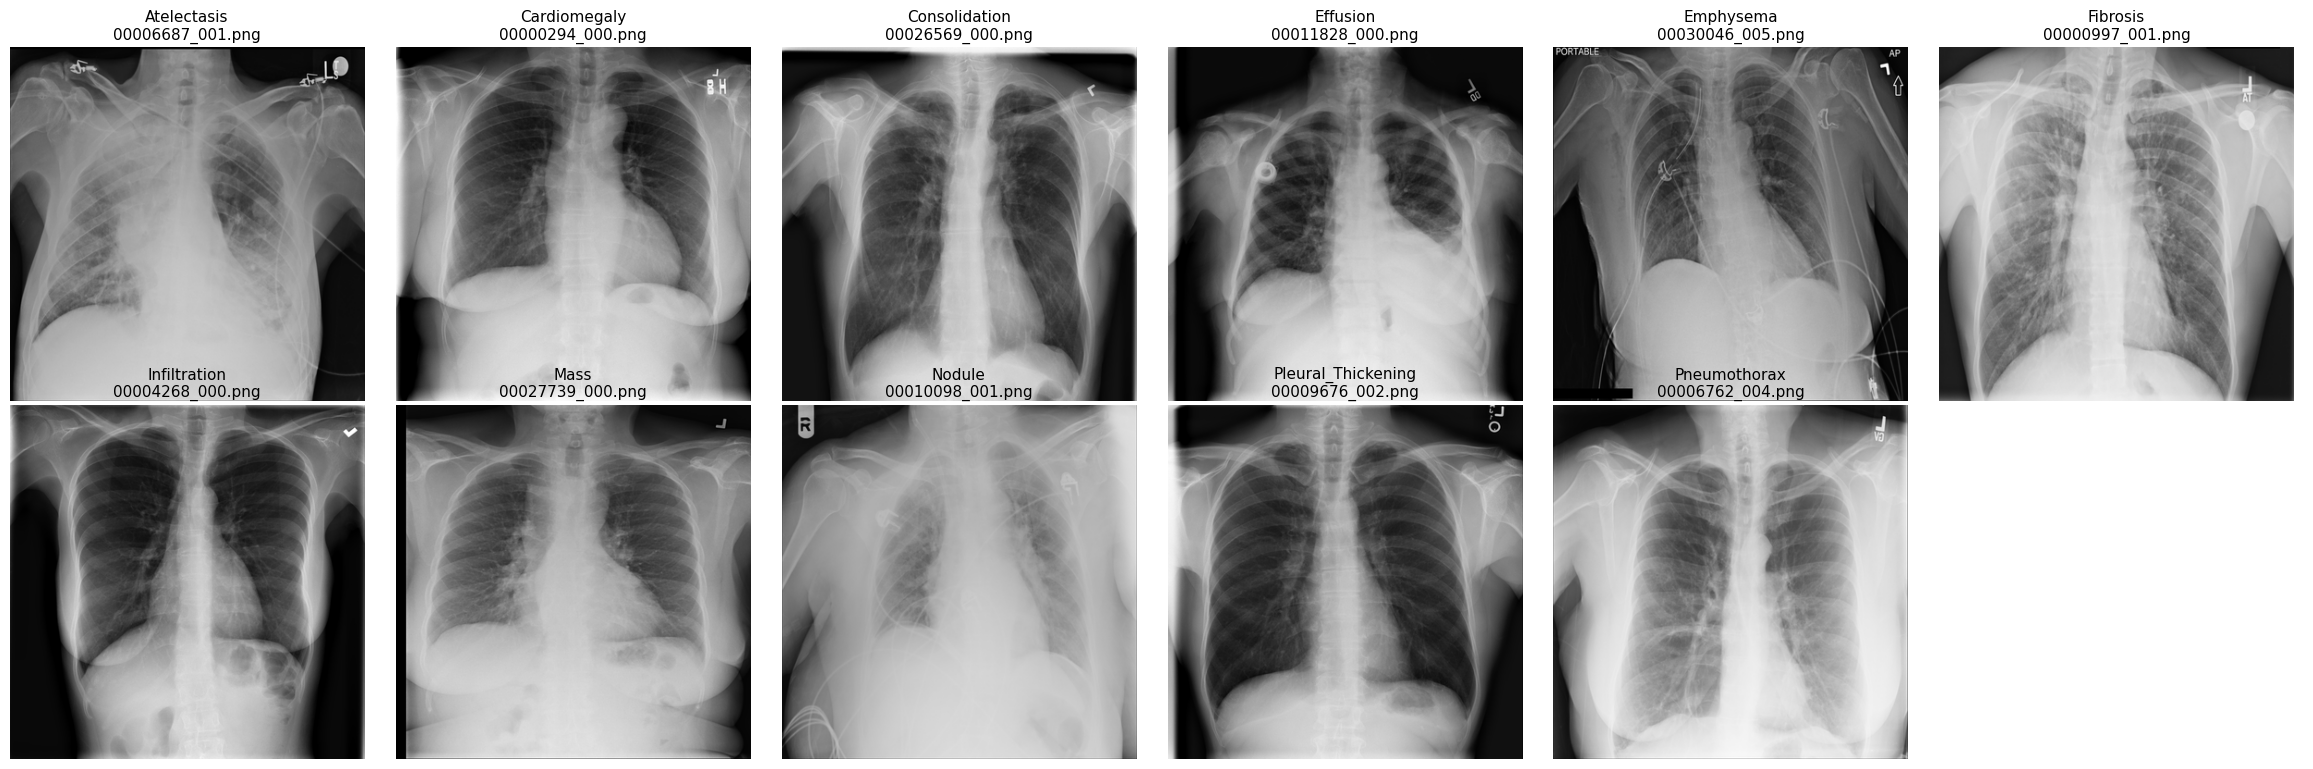

Displayed images: 11
Classes shown: Atelectasis, Cardiomegaly, Consolidation, Effusion, Emphysema, Fibrosis, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumothorax


In [13]:
# Random 11 images with their linked classes (simple + standalone fallback)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

if "df_filtered" in globals():
    sample_df = df_filtered.copy()
elif "df_one_image_per_patient" in globals():
    sample_df = df_one_image_per_patient.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Data_Entry_2017.csv not found.")

    base_df = pd.read_csv(csv_path)
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column not found.")

    work = base_df[~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")].copy()
    one_label = work[work["Finding Labels"].fillna("").astype(str).str.split("|").str.len().eq(1)].copy()
    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in one_label.columns else [])
    sample_df = one_label.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first").copy()

if "Finding Labels" not in sample_df.columns or "Image Index" not in sample_df.columns:
    raise KeyError("Required columns 'Finding Labels' and 'Image Index' were not found.")

selected = (
    sample_df[sample_df["Finding Labels"].fillna("").astype(str).str.strip().ne("")]
    .sample(frac=1)
    .drop_duplicates(subset="Finding Labels", keep="first")
    .sample(n=min(11, sample_df["Finding Labels"].nunique()))
    .sort_values("Finding Labels")
)

img_dir = next((d for d in [Path("archive") / "images_384", Path("images_384")] if d.exists()), None)
if img_dir is None:
    raise FileNotFoundError("images_384 folder not found. Run the resize cell first.")

selected = selected.copy()
selected["_img_path"] = selected["Image Index"].astype(str).apply(lambda x: img_dir / x)
selected = selected[selected["_img_path"].apply(lambda p: p.exists())].copy()
if selected.empty:
    raise FileNotFoundError("No sampled image files found in images_384.")

fig, axes = plt.subplots(2, 6, figsize=(24, 8), dpi=100)
axes = axes.ravel()
for i, ax in enumerate(axes):
    if i < len(selected):
        row = selected.iloc[i]
        ax.imshow(plt.imread(row["_img_path"]), cmap="gray")
        ax.set_title(f"{row['Finding Labels']}\n{row['Image Index']}", fontsize=11)
    ax.axis("off")

fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.04, wspace=0.03, hspace=0.01)
plt.show()

print(f"Displayed images: {len(selected)}")
print("Classes shown:", ", ".join(selected["Finding Labels"].tolist()))

## Data Splitting:

This step uses all available images from the retained 11 classes (no per-class downsampling).

A stratified split is applied to preserve class proportions across training (80%), validation (10%), and test (10%) sets for fair evaluation.

In [14]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Start with filtered or unfiltered dataset
if "df_filtered" in globals():
    split_source_df = df_filtered.copy()
elif "df_one_image_per_patient" in globals():
    split_source_df = df_one_image_per_patient.copy()
else:
    csv_candidates = [
        Path(globals().get("data_path", "data")) / "Data_Entry_2017.csv",
        Path("Data_Entry_2017.csv"),
        Path("archive") / "Data_Entry_2017.csv",
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), None)
    if csv_path is None:
        raise FileNotFoundError("Could not find Data_Entry_2017.csv")

    base_df = pd.read_csv(csv_path)
    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in base_df.columns), None)
    if patient_col is None:
        raise KeyError("Patient ID column was not found in the dataframe.")

    disease_df = base_df.loc[
        ~base_df["Finding Labels"].fillna("").str.strip().str.casefold().eq("no finding")
    ].copy()
    label_count = disease_df["Finding Labels"].fillna("").astype(str).str.split("|").str.len()
    single_label_df = disease_df.loc[label_count == 1].copy()

    patient_col = next((c for c in ["Patient ID", "PatientID", "patient_id"] if c in single_label_df.columns), None)
    sort_cols = [patient_col] + (["Image Index"] if "Image Index" in single_label_df.columns else [])
    split_source_df = single_label_df.sort_values(sort_cols).drop_duplicates(subset=patient_col, keep="first").copy()

required_cols = ["Finding Labels", "Image Index"]
missing_cols = [c for c in required_cols if c not in split_source_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for split: {missing_cols}")

# Clean and prepare data
work_df = split_source_df.copy()
work_df["Finding Labels"] = work_df["Finding Labels"].fillna("").astype(str).str.strip()
work_df = work_df.loc[work_df["Finding Labels"].ne("")].copy()

# Use ALL available data (no per-class cap)
full_df = work_df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print("Class distribution (all available data):")
print(full_df["Finding Labels"].value_counts())
print(f"\nTotal images used: {len(full_df)}")
print(f"Total classes: {full_df['Finding Labels'].nunique()}")

# Perform stratified train/val/test split on full data
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=full_df["Finding Labels"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=temp_df["Finding Labels"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n--- Stratified Split (80% train, 10% val, 10% test) ---")
print(f"Sample size used: {len(full_df)}")
print(f"Train size: {len(train_df)} ({len(train_df)/len(full_df):.2%})")
print(f"Val size:   {len(val_df)} ({len(val_df)/len(full_df):.2%})")
print(f"Test size:  {len(test_df)} ({len(test_df)/len(full_df):.2%})")

summary_df = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "pct": [
            len(train_df) / len(full_df),
            len(val_df) / len(full_df),
            len(test_df) / len(full_df),
        ],
    }
)
display(summary_df)

overall_dist = full_df["Finding Labels"].value_counts(normalize=True).sort_index()
train_dist = train_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
val_dist = val_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)
test_dist = test_df["Finding Labels"].value_counts(normalize=True).reindex(overall_dist.index, fill_value=0)

dist_check = pd.DataFrame(
    {
        "overall": overall_dist,
        "train": train_dist,
        "val": val_dist,
        "test": test_dist,
    }
).round(4)

display(dist_check)

Class distribution (all available data):
Finding Labels
Infiltration          4212
Atelectasis           1738
Nodule                1348
Effusion               994
Mass                   946
Cardiomegaly           611
Pleural_Thickening     540
Pneumothorax           446
Fibrosis               424
Emphysema              350
Consolidation          312
Name: count, dtype: int64

Total images used: 11921
Total classes: 11

--- Stratified Split (80% train, 10% val, 10% test) ---
Sample size used: 11921
Train size: 9536 (79.99%)
Val size:   1192 (10.00%)
Test size:  1193 (10.01%)


,split,rows,pct
0,train,9536,0.799933
1,val,1192,0.099992
2,test,1193,0.100075


,overall,train,val,test
Finding Labels,,,,
Atelectasis,0.1458,0.1458,0.1460,0.1459
Cardiomegaly,0.0513,0.0513,0.0512,0.0511
Consolidation,0.0262,0.0262,0.0260,0.0260
Effusion,0.0834,0.0834,0.0831,0.0838
Emphysema,0.0294,0.0294,0.0294,0.0293
Fibrosis,0.0356,0.0355,0.0361,0.0352
Infiltration,0.3533,0.3533,0.3532,0.3537
Mass,0.0794,0.0794,0.0789,0.0796
Nodule,0.1131,0.1130,0.1133,0.1132


--------------------------------

# Classifier 

In [15]:
from pathlib import Path
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision
from torchvision import transforms
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, TQDMProgressBar, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from torchmetrics.classification import MulticlassAccuracy

L.seed_everything(42)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for this notebook.")
print("Using device: cuda")

if not all(name in globals() for name in ["train_df", "val_df", "test_df"]):
    raise RuntimeError("train_df/val_df/test_df not found. Run the Data Splitting cell first.")

def first_existing_path(candidates):
    return next((p for p in candidates if p.exists()), None)

def build_lookup(roots):
    lookup = {}
    for root in roots:
        if root.exists():
            for p in root.glob("*.png"):
                lookup.setdefault(p.name, p)
    return lookup

def load_bbox_lookup():
    bbox_csv = first_existing_path([
        Path("archive") / "BBox_List_2017.csv",
        Path("BBox_List_2017.csv"),
    ])
    if bbox_csv is None:
        return {}

    bbox_df = pd.read_csv(bbox_csv, usecols=range(6))
    bbox_df.columns = ["Image Index", "Finding Label", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]
    bbox_df = bbox_df.dropna(subset=["Image Index", "Finding Label", "bbox_x", "bbox_y", "bbox_w", "bbox_h"])

    lookup = {}
    for _, row in bbox_df.iterrows():
        key = (str(row["Image Index"]), str(row["Finding Label"]))
        lookup.setdefault(key, []).append(
            (float(row["bbox_x"]), float(row["bbox_y"]), float(row["bbox_w"]), float(row["bbox_h"]))
        )
    return lookup

def crop_to_bboxes(image, boxes, padding_ratio=0.15):
    if not boxes:
        return image
    img_w, img_h = image.size
    x1 = min(x for x, y, w, h in boxes)
    y1 = min(y for x, y, w, h in boxes)
    x2 = max(x + w for x, y, w, h in boxes)
    y2 = max(y + h for x, y, w, h in boxes)
    pad_w = (x2 - x1) * padding_ratio
    pad_h = (y2 - y1) * padding_ratio
    left = max(0, int(round(x1 - pad_w)))
    top = max(0, int(round(y1 - pad_h)))
    right = min(img_w, int(round(x2 + pad_w)))
    bottom = min(img_h, int(round(y2 + pad_h)))
    return image if right <= left or bottom <= top else image.crop((left, top, right, bottom))

resized_root = first_existing_path([Path("archive") / "images_384", Path("images_384")])
if resized_root is None:
    raise FileNotFoundError("images_384 folder not found.")

orig_roots = []
for base in [Path("."), Path("archive")]:
    orig_roots.extend(sorted(base.glob("images_*/images")))

resized_lookup = build_lookup([resized_root])
orig_lookup = build_lookup(orig_roots)
bbox_lookup = load_bbox_lookup()

label_col = "Finding Labels"
image_col = "Image Index"

all_labels = sorted(train_df[label_col].astype(str).str.strip().unique().tolist())
label_to_idx = {label: i for i, label in enumerate(all_labels)}
idx_to_label = {i: label for label, i in label_to_idx.items()}
num_classes = len(all_labels)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
for split_df in [train_df, val_df, test_df]:
    split_df[label_col] = split_df[label_col].astype(str).str.strip()
    split_df["_image_path"] = split_df[image_col].astype(str).map(resized_lookup)
    split_df.dropna(subset=["_image_path"], inplace=True)

class XraySingleLabelDataset(Dataset):
    def __init__(self, frame, transform, use_bbox_crop=True):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.use_bbox_crop = use_bbox_crop

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image_name = str(row[image_col])
        label = str(row[label_col])

        image_path = row["_image_path"]
        if self.use_bbox_crop and bbox_lookup:
            image_path = orig_lookup.get(image_name, image_path)

        image = Image.open(image_path).convert("RGB")
        if self.use_bbox_crop and bbox_lookup:
            boxes = bbox_lookup.get((image_name, label))
            if boxes:
                image = crop_to_bboxes(image, boxes)

        return self.transform(image), label_to_idx[label]

train_tfms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_test_tfms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

USE_BBOX_FOR_TRAIN = True
train_ds = XraySingleLabelDataset(train_df, train_tfms, use_bbox_crop=USE_BBOX_FOR_TRAIN)
val_ds = XraySingleLabelDataset(val_df, val_test_tfms, use_bbox_crop=True)
test_ds = XraySingleLabelDataset(test_df, val_test_tfms, use_bbox_crop=True)

batch_size = 16
num_workers = 0 if os.name == "nt" else max(4, min(12, (os.cpu_count() or 4) - 1))
loader_common = {"num_workers": num_workers, "pin_memory": True}
if num_workers > 0:
    loader_common["persistent_workers"] = True
    loader_common["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, **loader_common)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **loader_common)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, **loader_common)

print(f"Number of classes: {num_classes}")
print(f"BBox crop status -> train: {USE_BBOX_FOR_TRAIN}, val: True, test: True")
print(f"DataLoader settings -> num_workers: {num_workers}, pin_memory: True")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Seed set to 42


Using device: cuda
Number of classes: 11
BBox crop status -> train: True, val: True, test: True
DataLoader settings -> num_workers: 0, pin_memory: True
Train batches: 596 | Val batches: 75 | Test batches: 75


In [16]:
from lightning.pytorch.callbacks import ModelCheckpoint, TQDMProgressBar, EarlyStopping

class XrayClassifier(L.LightningModule):
    def __init__(self, n_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.backbone = torchvision.models.swin_t(weights="DEFAULT")
        in_features = self.backbone.head.in_features
        self.backbone.head = torch.nn.Linear(in_features, n_classes)
        self.criterion = torch.nn.CrossEntropyLoss()
        self.train_acc = MulticlassAccuracy(num_classes=n_classes)
        self.val_acc = MulticlassAccuracy(num_classes=n_classes)

    def forward(self, x):
        return self.backbone(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

model = XrayClassifier(n_classes=num_classes, lr=1e-4)

logger = CSVLogger(save_dir="archive", name="xray_training_logs")
checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    save_last=True,
    every_n_epochs=1,
    filename="best-{epoch:02d}-{val_loss:.4f}",
)
progress_bar_cb = TQDMProgressBar(refresh_rate=10)
early_stop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=4,
    min_delta=1e-4,
    verbose=True,
)

trainer = L.Trainer(
    max_epochs=20,
    logger=logger,
    callbacks=[checkpoint_cb, progress_bar_cb, early_stop_cb],
    enable_progress_bar=True,
    enable_checkpointing=True,
    log_every_n_steps=5,
    benchmark=True,
    deterministic=False,
    **trainer_kwargs,
)

print("Early stopping enabled: monitor=val_loss, mode=min, patience=4, min_delta=1e-4")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Early stopping enabled: monitor=val_loss, mode=min, patience=4, min_delta=1e-4


# Training

In [17]:
if "trainer" not in globals() or "model" not in globals() or "train_loader" not in globals() or "val_loader" not in globals():
    raise RuntimeError("Trainer/model/dataloaders not found. Run the Classifier cell first.")

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader, ckpt_path=None)

print(f"Training complete. Logs: {trainer.logger.log_dir}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ SwinTransformer    │ 27.5 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 27.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.5 M                                                                                               
Total estimated model params size (MB): 110                                                                        
Modules in train mode: 183                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rabi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Epoch 7: 100%|██████████| 596/596 [02:22<00:00,  4.17it/s, v_num=8, val_loss=1.590, val_acc=0.305, train_loss=1.330, train_acc=0.385]

Metric val_loss improved by 0.018 >= min_delta = 0.0001. New best score: 1.590


Epoch 11: 100%|██████████| 596/596 [02:22<00:00,  4.18it/s, v_num=8, val_loss=1.780, val_acc=0.308, train_loss=0.940, train_acc=0.558]

Monitored metric val_loss did not improve in the last 4 records. Best score: 1.590. Signaling Trainer to stop.


Epoch 11: 100%|██████████| 596/596 [02:22<00:00,  4.18it/s, v_num=8, val_loss=1.780, val_acc=0.308, train_loss=0.940, train_acc=0.558]
Training complete. Logs: archive\xray_training_logs\version_8


# validation chart 

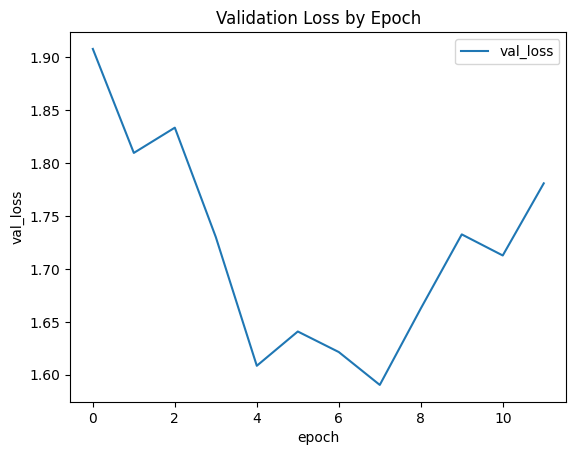

In [18]:
import os
import pandas as pd

if "trainer" not in globals() or getattr(trainer, "logger", None) is None:
    raise RuntimeError("Trainer/logs not found. Run the Training cell first.")

metrics = pd.read_csv(os.path.join(trainer.logger.log_dir, "metrics.csv"))
loss_metrics = metrics[["epoch", "val_loss"]].dropna(subset=["val_loss"]).set_index("epoch")
plot = loss_metrics.plot(title="Validation Loss by Epoch", ylabel="val_loss")

# Overall Metrics

In [19]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "model" not in globals() or "test_loader" not in globals():
    raise RuntimeError("Model or test_loader not found. Run the Training cell first.")

eval_device = next(model.parameters()).device
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(eval_device)
        targets = targets.to(eval_device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

correct = (all_preds == all_targets).sum()
total = len(all_targets)
test_accuracy = correct / total if total > 0 else 0.0

print(f"Test samples: {total}")
print(f"Correct predictions: {correct}")
print(f"Overall Accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")
print("\n" + "=" * 80)
print("Per-Class Precision, Recall, and F1-Score:")
print("=" * 80)

if "idx_to_label" in globals():
    class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
else:
    class_names = [f"Class_{i}" for i in sorted(set(all_targets.tolist()) | set(all_preds.tolist()))]

print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))


Test samples: 1193
Correct predictions: 581
Overall Accuracy: 0.4870 (48.70%)

Per-Class Precision, Recall, and F1-Score:
                    precision    recall  f1-score   support

       Atelectasis     0.5156    0.3793    0.4371       174
      Cardiomegaly     0.5000    0.4918    0.4959        61
     Consolidation     0.1429    0.0968    0.1154        31
          Effusion     0.4886    0.4300    0.4574       100
         Emphysema     0.2105    0.1143    0.1481        35
          Fibrosis     0.3103    0.2143    0.2535        42
      Infiltration     0.5595    0.8128    0.6628       422
              Mass     0.4304    0.3579    0.3908        95
            Nodule     0.4082    0.2963    0.3433       135
Pleural_Thickening     0.0357    0.0185    0.0244        54
      Pneumothorax     0.2667    0.1818    0.2162        44

          accuracy                         0.4870      1193
         macro avg     0.3517    0.3085    0.3223      1193
      weighted avg     0.4524    0.4

# confusion Metric

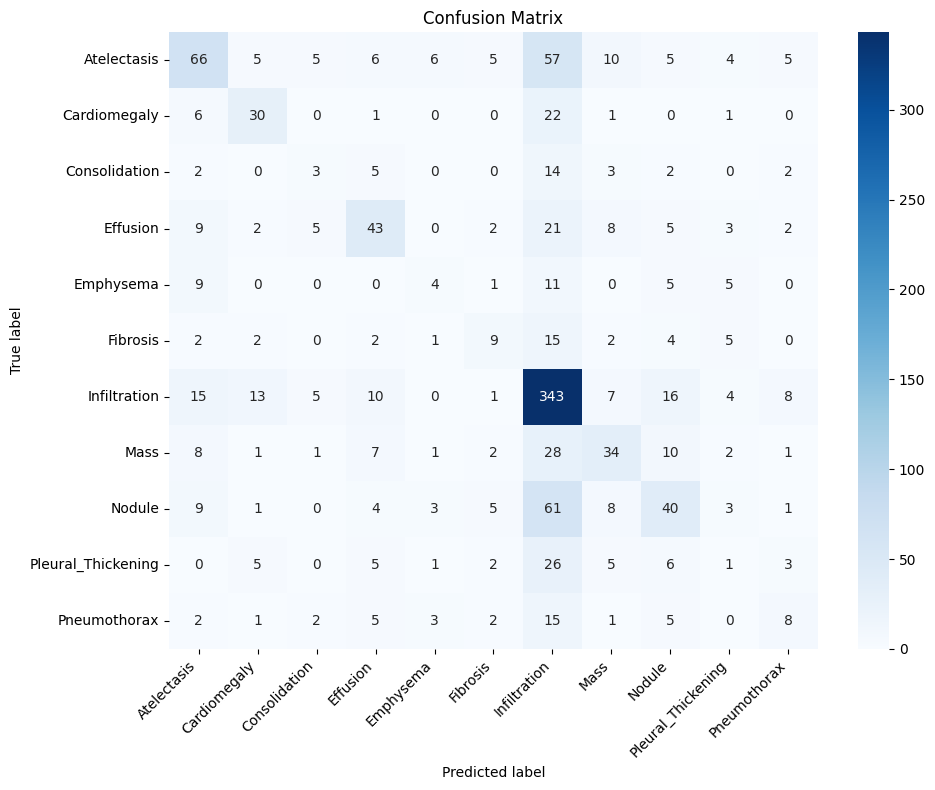


Most confused class pairs:


,True class,Predicted as,Count
0,Nodule,Infiltration,61
1,Atelectasis,Infiltration,57
2,Mass,Infiltration,28
3,Pleural_Thickening,Infiltration,26
4,Cardiomegaly,Infiltration,22
5,Effusion,Infiltration,21
6,Infiltration,Nodule,16
7,Pneumothorax,Infiltration,15
8,Fibrosis,Infiltration,15
9,Infiltration,Atelectasis,15


In [20]:

# Build confusion matrix
cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(class_names))))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Analyze the strongest confusions (off-diagonal entries)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

confusions = []
for true_idx in range(cm_off_diag.shape[0]):
    for pred_idx in range(cm_off_diag.shape[1]):
        count = int(cm_off_diag[true_idx, pred_idx])
        if count > 0:
            confusions.append(
                {
                    "True class": class_names[true_idx],
                    "Predicted as": class_names[pred_idx],
                    "Count": count,
                }
            )

if confusions:
    confusion_df = pd.DataFrame(confusions).sort_values("Count", ascending=False).reset_index(drop=True)
    print("\nMost confused class pairs:")
    display(confusion_df.head(10))
else:
    print("\nNo class confusions found on the test set.")